In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n=500


In [118]:
# Datos sinteticos
MedInc = np.random.lognormal(mean = 2.5, sigma=.35, size=n)
HouseAge = np.random.randint(1, 52, size=n)
Longitude = -124 + np.random.rand(n) * 10
Latitude = 32 + np.random.rand(n) * 8
AveRooms = 5 + .15*MedInc+ .03*HouseAge + np.random.rand(n)

#target
target = (
    .45*MedInc
    - .02*HouseAge
    -.3*(Latitude-36)
    -.1*(Longitude-119)
    +np.random.randn(n)*.5
    +AveRooms*.02
)

In [119]:
df = pd.DataFrame(
    {
        'MedInc': MedInc,
        'HouseAge': HouseAge,
        'Longitude': Longitude,
        'Latitude': Latitude,
        'AveRooms': AveRooms,
        'target': target
    }
)

numeric_cols = df.columns.tolist()

In [120]:
cov_mat = df[numeric_cols].cov()
corr_mat = df[numeric_cols].corr()

print(f'Covariance matrix: \n {cov_mat.round(3)}')
print(f'Correlation matrix: \n {corr_mat.round(3)}')

Covariance matrix: 
            MedInc  HouseAge  Longitude  Latitude  AveRooms  target
MedInc     22.967    -3.196      0.114     0.694     3.249  10.322
HouseAge   -3.196   222.304     -2.162    -0.080     6.056  -5.772
Longitude   0.114    -2.162      8.644     0.390    -0.037  -0.897
Latitude    0.694    -0.080      0.390     5.031     0.112  -1.284
AveRooms    3.249     6.056     -0.037     0.112     0.736   1.335
target     10.322    -5.772     -0.897    -1.284     1.335   5.572
Correlation matrix: 
            MedInc  HouseAge  Longitude  Latitude  AveRooms  target
MedInc      1.000    -0.045      0.008     0.065     0.790   0.912
HouseAge   -0.045     1.000     -0.049    -0.002     0.473  -0.164
Longitude   0.008    -0.049      1.000     0.059    -0.015  -0.129
Latitude    0.065    -0.002      0.059     1.000     0.058  -0.243
AveRooms    0.790     0.473     -0.015     0.058     1.000   0.659
target      0.912    -0.164     -0.129    -0.243     0.659   1.000


In [121]:
#Hat matrix
y = df['target'].values.reshape(-1,1)
X = df[["MedInc", "AveRooms", "HouseAge",  "Latitude", "Longitude"]].values

In [122]:
XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)
beta = XtX_inv @ X.T @ y
y_hat = X @ beta

residuals = y - y_hat

#Hat matrix
H = X @ XtX_inv @ X.T
leverage = np.diag(H)

In [123]:
print(leverage)

[0.0067846  0.00791982 0.00847013 0.0172161  0.00440733 0.00525745
 0.01259694 0.00977876 0.01533073 0.01202658 0.00705151 0.01075252
 0.00231869 0.0089819  0.00833198 0.00455737 0.00432348 0.00839827
 0.01196354 0.01361989 0.00732749 0.01285226 0.01140345 0.00569535
 0.01645572 0.0037665  0.01420947 0.00848022 0.00989076 0.0027566
 0.00841421 0.02416634 0.00878854 0.01549929 0.0140942  0.01317021
 0.00470178 0.01161905 0.01379405 0.00339667 0.00505214 0.00815537
 0.00805921 0.00793624 0.00830129 0.00969073 0.00709981 0.01711625
 0.00723452 0.01873673 0.0031081  0.00460647 0.00491858 0.00467417
 0.01330143 0.01080364 0.01133873 0.00894425 0.00300966 0.0110635
 0.00629195 0.0051693  0.00874045 0.00728413 0.00489302 0.0156464
 0.01711969 0.00577284 0.01269716 0.01077955 0.00696396 0.01324823
 0.0039508  0.01208273 0.01835672 0.01415091 0.00409896 0.00691866
 0.00999249 0.00685658 0.00994668 0.01269986 0.02038301 0.00444865
 0.0071463  0.00558483 0.0100084  0.00937241 0.00991305 0.0055030

In [124]:
print('H', H.shape)
print('y', y.shape)
print('X', X.shape)
print('beta', beta.shape)

H (500, 500)
y (500, 1)
X (500, 5)
beta (5, 1)


In [125]:
summary = pd.DataFrame({
    'index': np.arange(n),
    'leverage': leverage,
    'y': y.flatten(),
    'y_hat': y_hat.flatten(),
    'resid': residuals.flatten()
}
)

In [126]:
print('Top Ten Leverage Points')
print(summary.sort_values(by='leverage', ascending=False).head(10).round(3))

Top Ten Leverage Points
     index  leverage       y   y_hat  resid
209    209     0.115  45.610  46.759 -1.149
478    478     0.052  40.237  40.086  0.152
179    179     0.034  37.909  38.264 -0.355
234    234     0.028  33.055  33.028  0.027
220    220     0.028  35.789  35.908 -0.119
113    113     0.028  36.417  35.760  0.656
323    323     0.024  33.130  33.135 -0.005
31      31     0.024  34.119  33.333  0.787
284    284     0.024  36.291  35.036  1.255
252    252     0.024  35.309  34.203  1.107


In [127]:
n, p = X.shape
avg_lev = p/n
treshold = 2*avg_lev

print('avg_lev ', avg_lev)
print('treshold ', treshold)

avg_lev  0.01
treshold  0.02


<function matplotlib.pyplot.show(close=None, block=None)>

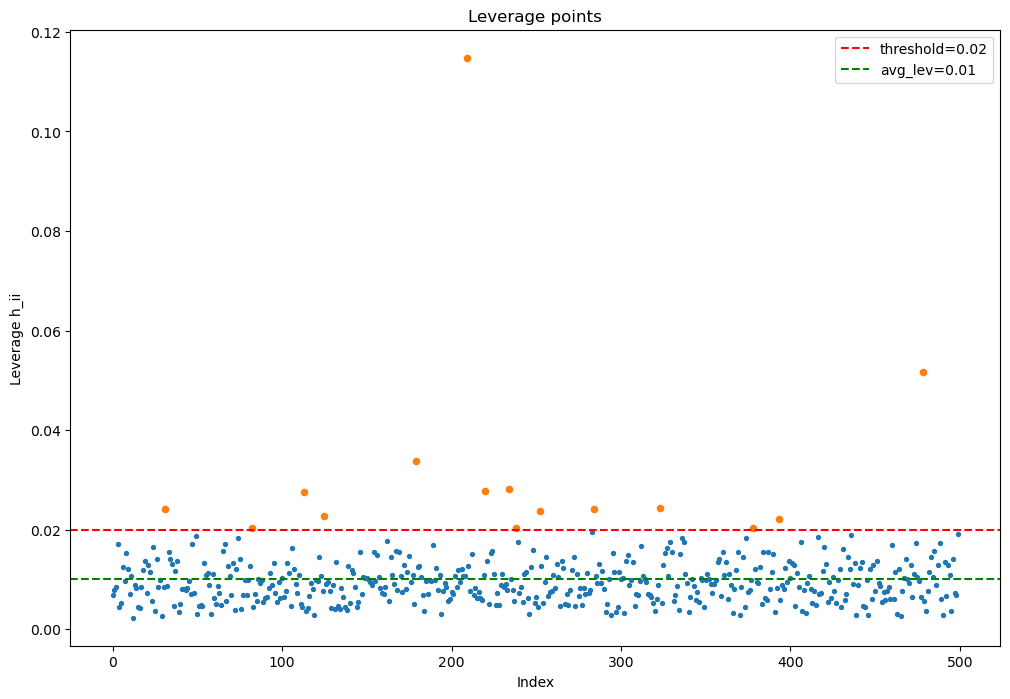

In [128]:
#Plotting leverage points
plt.figure(figsize=(12, 8))
plt.scatter(summary["index"], summary["leverage"], s=8)
plt.axhline(treshold, color="r", linestyle="--", label=f"threshold={treshold:.2f}")
plt.axhline(avg_lev, color='g', linestyle="--", label=f"avg_lev={avg_lev:.2f}")
hi_idx = summary.index[summary["leverage"]>treshold].tolist()
if len(hi_idx) > 0:
    plt.scatter(hi_idx, summary.loc[hi_idx, "leverage"], s=20)
plt.title("Leverage points")
plt.xlabel("Index")
plt.ylabel("Leverage h_ii")
plt.legend()
plt.show 

In [129]:
import statsmodels.api as sm

In [130]:
#Generate synthetic data
np.random.seed(0)

#Normal house
house_size = np.random.normal(2000, 400, 100)
house_price = 100 + .5 * house_size + np.random.normal(0, 20000, 100)

#Add few mansion
house_size = np.append(house_size, [5000, 6000, 7000])
house_price = np.append(house_price, [450000, 550000, 800000])

#Fit a linear regression model
X = sm.add_constant(house_size)
model = sm.OLS(house_price, X).fit()

In [131]:
#printing parameters
print("Model with mansions:")
print(f'Intercept: {model.params[0]:.2f}')
print(f'Slope: {model.params[1]:.2f}')

Model with mansions:
Intercept: -225040.03
Slope: 114.59


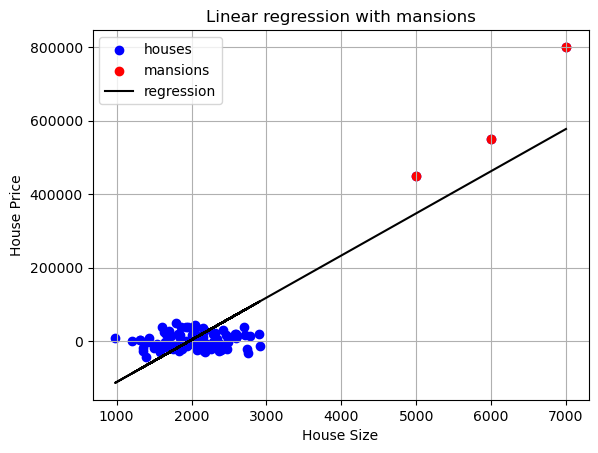

In [132]:
#Plot the data
plt.scatter(house_size, house_price, label='houses', color='blue')
plt.scatter(house_size[-3:], house_price[-3:], label='mansions', color='red')
plt.plot(house_size, model.params[0]+model.params[1]*house_size, label='regression', color='black')
plt.title('Linear regression with mansions')
plt.xlabel('House Size')
plt.ylabel('House Price')
plt.legend()
plt.grid(True)
plt.show()

In [133]:
#Get the leverage points
influence = model.get_influence()
leverage = influence.hat_matrix_diag
residuals = model.resid

#Threshold
n = len(house_size)
p = X.shape[1]
avg_lev = p/n
treshold = 2*avg_lev

print(treshold)


0.038834951456310676


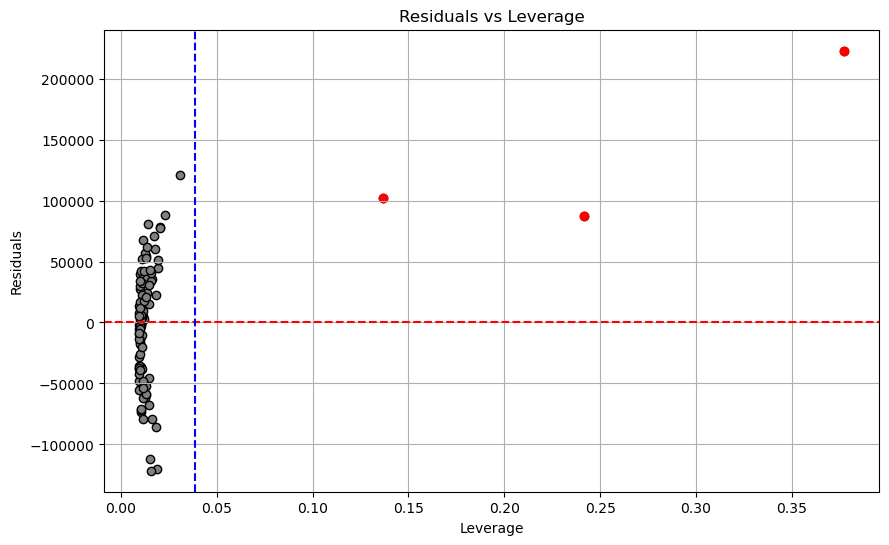

In [134]:
plt.figure(figsize=(10,6))
plt.scatter(leverage, residuals, edgecolors='k', facecolor='gray')
plt.axhline(0, color='red', linestyle='--')
plt.axvline(treshold, color='blue', linestyle='--')
plt.xlabel('Leverage')
plt.ylabel('Residuals')
plt.title('Residuals vs Leverage')
plt.grid(True)
high_leverage_points = np.where(leverage>treshold)[0]
plt.scatter(leverage[high_leverage_points], residuals[high_leverage_points], color='red', label='High leverage points')
plt.show()

Excercise 1

In [135]:
df = pd.read_csv('HousingData.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [136]:
print(df.isnull().sum())
df.dropna(subset=['CRIM', 'ZN', 'INDUS', 'CHAS', 'AGE', 'LSTAT'], inplace=True)
print()
print(df.isnull().sum())

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [137]:
X = df[df.columns.drop('MEDV')]
y = df['MEDV']

In [138]:
model = sm.OLS(y, X).fit()

In [139]:
#Get the leverage points
influence = model.get_influence()
leverage = influence.hat_matrix_diag
residuals = model.resid

#Threshold
n = len(house_size)
p = X.shape[1]
avg_lev = p/n
treshold = 2*avg_lev

print(treshold)


0.2524271844660194


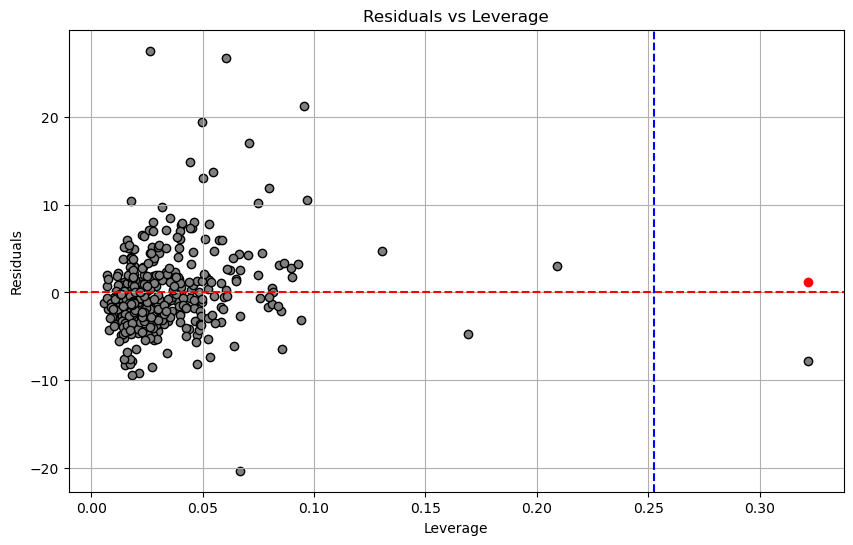

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(leverage, residuals, edgecolors='k', facecolor='gray')
plt.axhline(0, color='red', linestyle='--')
plt.axvline(treshold, color='blue', linestyle='--')
plt.xlabel('Leverage')
plt.ylabel('Residuals')
plt.title('Residuals vs Leverage')
plt.grid(True)
high_leverage_points = np.where(leverage>treshold)[0]
plt.scatter(leverage[high_leverage_points], residuals[high_leverage_points], color='red', label='High leverage points')
plt.show()

In [141]:
print(leverage[high_leverage_points])

[0.32195505]


Ejercicio 2

In [142]:
import seaborn as sns

In [143]:
diamonds = sns.load_dataset("diamonds")
print(diamonds.head())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


In [144]:
print(diamonds.isnull().sum())

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [152]:
df_encoded = pd.get_dummies(diamonds, columns=['cut', 'color', 'clarity'], prefix=['cut', 'color', 'clarity']).astype(int)
df_encoded.head()

,carat,depth,table,price,x,y,z,cut_Ideal,cut_Premium,cut_Very Good,...,color_I,color_J,clarity_IF,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0,61,55,326,3,3,2,1,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,59,61,326,3,3,2,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,0,56,65,327,4,4,2,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,62,58,334,4,4,2,0,1,0,...,1,0,0,0,0,0,1,0,0,0
4,0,63,58,335,4,4,2,0,0,0,...,0,1,0,0,0,0,0,0,1,0


In [153]:
df_encoded = df_encoded.apply(pd.to_numeric, errors='coerce')

In [154]:
X = df_encoded[df_encoded.columns.drop('price')]
y = df_encoded['price']

In [155]:
model = sm.OLS(y, X).fit()

In [156]:
#Get the leverage points
influence = model.get_influence()
leverage = influence.hat_matrix_diag
residuals = model.resid

#Threshold
n = len(house_size)
p = X.shape[1]
avg_lev = p/n
treshold = 2*avg_lev

print(treshold)

0.5048543689320388


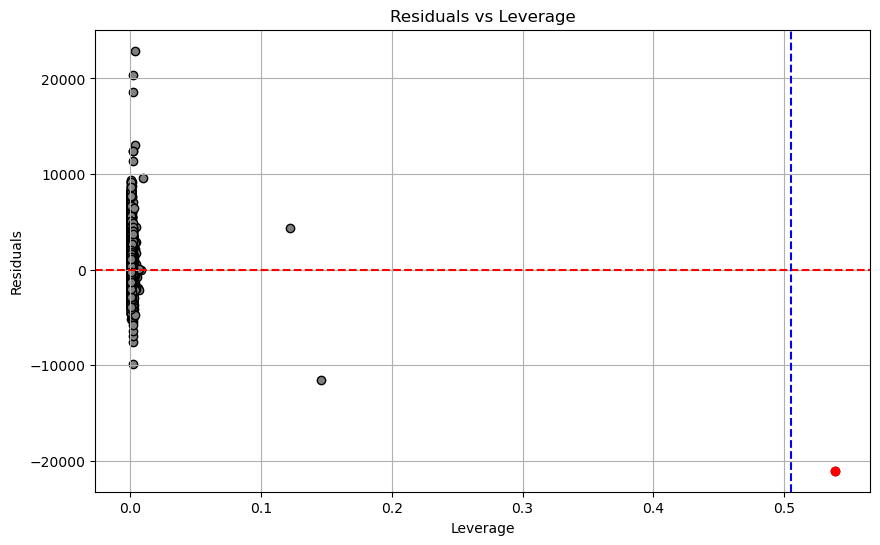

In [157]:
plt.figure(figsize=(10,6))
plt.scatter(leverage, residuals, edgecolors='k', facecolor='gray')
plt.axhline(0, color='red', linestyle='--')
plt.axvline(treshold, color='blue', linestyle='--')
plt.xlabel('Leverage')
plt.ylabel('Residuals')
plt.title('Residuals vs Leverage')
plt.grid(True)
high_leverage_points = np.where(leverage>treshold)[0]
plt.scatter(leverage[high_leverage_points], residuals[high_leverage_points], color='red', label='High leverage points')
plt.show()

In [158]:
print(leverage[high_leverage_points])

[0.53890583]
